In [1]:
import os
import duckdb
import pandas as pd
import numpy as np

# Always resolve paths relative to project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

DB_PATH = os.path.abspath("data/ecommerce.db")
assert os.path.exists(DB_PATH), f"DB not found at {DB_PATH}"
con = duckdb.connect(DB_PATH)
print(f"Connected: {DB_PATH}")
print(f"Working dir: {os.getcwd()}")

Connected: c:\Users\SUMANT\Desktop\ecommerce-sales-analysis\data\ecommerce.db
Working dir: c:\Users\SUMANT\Desktop\ecommerce-sales-analysis


In [2]:
# Snapshot date = day after the last order in the dataset
snapshot = con.execute("""
    SELECT MAX(purchased_at)::DATE + INTERVAL '1 day' AS snapshot
    FROM orders_clean
""").fetchone()[0]

print(f"Snapshot date: {snapshot}")
# Expected: 2018-10-18

Snapshot date: 2018-10-18 00:00:00


In [3]:
customer_base = con.execute("""
    SELECT DISTINCT customer_id
    FROM orders_clean
    WHERE order_status = 'delivered'
""").df()

print(f"Customer base: {len(customer_base):,} customers")
# Expected: ~96,000

Customer base: 96,478 customers


In [4]:
rfm = con.execute(f"""
    WITH delivered AS (
        SELECT
            o.customer_id,
            o.purchased_at,
            o.order_id,
            SUM(oi.price) AS order_revenue
        FROM orders_clean o
        JOIN order_items_clean oi USING (order_id)
        WHERE o.order_status = 'delivered'
        GROUP BY o.customer_id, o.purchased_at, o.order_id
    )
    SELECT
        customer_id,

        -- Recency: days since last purchase (lower = more recent = better)
        DATE_DIFF('day',
            MAX(purchased_at)::DATE,
            DATE '{snapshot}'
        )                                   AS recency_days,

        -- Frequency: number of delivered orders
        COUNT(DISTINCT order_id)            AS frequency,

        -- Monetary: total spend across all delivered orders
        ROUND(SUM(order_revenue), 2)        AS monetary,

        -- Average order value
        ROUND(AVG(order_revenue), 2)        AS avg_order_value,

        -- First and last order dates (useful for tenure)
        MIN(purchased_at)::DATE             AS first_order_date,
        MAX(purchased_at)::DATE             AS last_order_date,

        -- Customer tenure in days
        DATE_DIFF('day',
            MIN(purchased_at)::DATE,
            DATE '{snapshot}'
        )                                   AS tenure_days

    FROM delivered
    GROUP BY customer_id
""").df()

print(rfm.shape)
print(rfm.describe().round(2))

(96478, 8)
       recency_days  frequency  monetary  avg_order_value  \
count      96478.00    96478.0  96478.00         96478.00   
mean         289.66        1.0    137.04           137.04   
min           50.00        1.0      0.85             0.85   
25%          166.00        1.0     45.90            45.90   
50%          271.00        1.0     86.57            86.57   
75%          399.00        1.0    149.90           149.90   
max          763.00        1.0  13440.00         13440.00   
std          152.84        0.0    209.05           209.05   

                 first_order_date             last_order_date  tenure_days  
count                       96478                       96478     96478.00  
mean   2018-01-01 08:13:06.881983  2018-01-01 08:13:06.881983       289.66  
min           2016-09-15 00:00:00         2016-09-15 00:00:00        50.00  
25%           2017-09-14 00:00:00         2017-09-14 00:00:00       166.00  
50%           2018-01-20 00:00:00         2018-01-20 0

In [5]:
category_diversity = con.execute("""
    SELECT
        o.customer_id,
        COUNT(DISTINCT p.category_en)   AS category_diversity,
        MODE(p.category_en)             AS favourite_category
    FROM orders_clean o
    JOIN order_items_clean oi USING (order_id)
    JOIN products_clean p     USING (product_id)
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
""").df()

print(category_diversity.head())

                        customer_id  category_diversity favourite_category
0  c15eed3881abc9e06763c989679c5094                   1          perfumery
1  23c60a0f388a1d3c11354d5b31e09993                   1         cool_stuff
2  98dbd4d2aa22a4b4a06bf84781432636                   1       garden_tools
3  b21abdbd6175139c4e9b66ee64f9c87a                   1          telephony
4  4845d49bb7438b41285097b65d1d3400                   1     bed_bath_table


In [6]:
review_features = con.execute("""
    SELECT
        o.customer_id,
        ROUND(AVG(r.review_score), 2)   AS avg_review_score,
        COUNT(r.review_score)           AS review_count,
        -- 1 if they ever left a review, 0 otherwise
        CASE WHEN COUNT(r.review_score) > 0 THEN 1 ELSE 0 END AS is_reviewer
    FROM orders_clean o
    LEFT JOIN reviews r USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
""").df()

print(review_features.head())

                        customer_id  avg_review_score  review_count  \
0  600a3fb4f5eab2e7de4eee159be73c81               5.0             1   
1  72889b03d4e898e80bf55ea7e36961a6               5.0             1   
2  47b778190ffdaf6fd31dc28330aeecd2               5.0             1   
3  dc607dc98d6a11d5d04d9f2a70aa6c34               1.0             1   
4  82aa082265445ca12f36a984d1e854e2               5.0             1   

   is_reviewer  
0            1  
1            1  
2            1  
3            1  
4            1  


In [7]:
delivery_features = con.execute("""
    SELECT
        customer_id,
        ROUND(AVG(actual_delivery_days), 1)  AS avg_delivery_days,
        ROUND(AVG(delivery_delta_days), 1)   AS avg_delivery_delta,
        -- positive delta = delivered early, negative = late
        SUM(CASE WHEN delivery_delta_days < 0 THEN 1 ELSE 0 END) AS late_deliveries,
        COUNT(*)                             AS total_delivered_orders
    FROM orders_clean
    WHERE order_status = 'delivered'
      AND actual_delivery_days IS NOT NULL
    GROUP BY customer_id
""").df()

print(delivery_features.head())

                        customer_id  avg_delivery_days  avg_delivery_delta  \
0  c77ee2d8ba1614a4d489a44166894938               18.0                 4.0   
1  be8c14c16a4d47194ccdfe10f1fc5b1a                5.0                 8.0   
2  f7398fc942c8fa80e5419ae52e49f7fb                5.0                 6.0   
3  cae507afa38570ca8b08ae0cbcadd5d5               10.0                16.0   
4  05535d34af5324aaf6988e1d890a0d6e                4.0                21.0   

   late_deliveries  total_delivered_orders  
0              0.0                       1  
1              0.0                       1  
2              0.0                       1  
3              0.0                       1  
4              0.0                       1  


In [8]:
payment_features = con.execute("""
    SELECT
        o.customer_id,
        MODE(p.payment_type)                    AS preferred_payment,
        ROUND(AVG(p.payment_installments), 1)   AS avg_installments,
        MAX(p.payment_installments)             AS max_installments,
        -- flag: ever paid in more than 6 installments
        MAX(CASE WHEN p.payment_installments > 6 THEN 1 ELSE 0 END) AS high_installment_flag
    FROM orders_clean o
    JOIN payments p USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
""").df()

print(payment_features.head())

                        customer_id preferred_payment  avg_installments  \
0  f2c7fc58a9de810828715166c672f10a       credit_card               1.0   
1  fcc4ed69deb551648926eab09355a9c5       credit_card               2.0   
2  6f750933c4466edfcd08b82f4ddfd920       credit_card               2.0   
3  c7ada2a2ca6ff94ccc7bbd16af1dec55       credit_card               2.0   
4  fe1ae0bf088bc446aa79c7f3c11d9fe2            boleto               1.0   

   max_installments  high_installment_flag  
0                 1                      0  
1                 2                      0  
2                 2                      0  
3                 2                      0  
4                 1                      0  


In [9]:
weekend_flag = con.execute("""
    SELECT
        customer_id,
        ROUND(
            AVG(CASE WHEN EXTRACT(dow FROM purchased_at) IN (0, 6) THEN 1.0 ELSE 0.0 END),
            3
        ) AS weekend_purchase_rate
    FROM orders_clean
    WHERE order_status = 'delivered'
    GROUP BY customer_id
""").df()

print(weekend_flag.head())

                        customer_id  weekend_purchase_rate
0  74805bc388861fa350ed2fade8444e0b                    1.0
1  61449fa1b8b8998c9c3f3a7f0ae954ef                    1.0
2  fa5c31ea5a141cb29a683b6420f2693a                    0.0
3  a51b373c427132a77b112ca10f502c4f                    0.0
4  597950088114c1a9e2b27459051f40ff                    1.0


In [10]:
freight_ratio = con.execute("""
    SELECT
        o.customer_id,
        ROUND(
            SUM(oi.freight_value) / NULLIF(SUM(oi.total_item_value), 0),
            4
        ) AS freight_to_revenue_ratio
    FROM orders_clean o
    JOIN order_items_clean oi USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY o.customer_id
""").df()

print(freight_ratio.head())

                        customer_id  freight_to_revenue_ratio
0  3ce436f183e68e07877b285a838db11a                    0.1841
1  d987da9fb4086ab7c2c0f83963cd6722                    0.2906
2  ab3642244247c0c638253fe68ee4c345                    0.7841
3  1aac2b5adf8aec2c00fe67d06aa8ebc2                    0.0292
4  399d1e628c48b7c3b6389098be566cfd                    0.0862


In [11]:
from functools import reduce

feature_frames = [
    rfm,
    category_diversity,
    review_features,
    delivery_features.drop(columns=['total_delivered_orders']),
    payment_features,
    weekend_flag,
    freight_ratio,
]

# Left join all on customer_id
features = reduce(
    lambda left, right: left.merge(right, on='customer_id', how='left'),
    feature_frames
)

print(f"\nFeature store shape: {features.shape}")
print(f"Columns: {list(features.columns)}")
print(features.head(3).T)


Feature store shape: (96478, 22)
Columns: ['customer_id', 'recency_days', 'frequency', 'monetary', 'avg_order_value', 'first_order_date', 'last_order_date', 'tenure_days', 'category_diversity', 'favourite_category', 'avg_review_score', 'review_count', 'is_reviewer', 'avg_delivery_days', 'avg_delivery_delta', 'late_deliveries', 'preferred_payment', 'avg_installments', 'max_installments', 'high_installment_flag', 'weekend_purchase_rate', 'freight_to_revenue_ratio']
                                                         0  \
customer_id               d73144ccd5680a3ed460ed34939c036e   
recency_days                                           262   
frequency                                                1   
monetary                                              99.9   
avg_order_value                                       99.9   
first_order_date                       2018-01-29 00:00:00   
last_order_date                        2018-01-29 00:00:00   
tenure_days                        

In [12]:
import matplotlib.pyplot as plt

skew_cols = ['recency_days', 'frequency', 'monetary', 'avg_order_value']

print("Skewness before transformation:")
for col in skew_cols:
    print(f"  {col}: {features[col].skew():.2f}")

# Log1p transform (handles zeros safely)
for col in ['frequency', 'monetary', 'avg_order_value']:
    features[f'log_{col}'] = np.log1p(features[col])

# Recency: invert first (high recency = bad), then log
features['log_recency'] = np.log1p(features['recency_days'].max() - features['recency_days'])

print("\nSkewness after log transform:")
for col in ['log_frequency', 'log_monetary', 'log_avg_order_value', 'log_recency']:
    print(f"  {col}: {features[col].skew():.2f}")

Skewness before transformation:
  recency_days: 0.43
  frequency: 0.00
  monetary: 9.89
  avg_order_value: 9.89

Skewness after log transform:
  log_frequency: -1.00
  log_monetary: 0.29
  log_avg_order_value: 0.29
  log_recency: -1.88


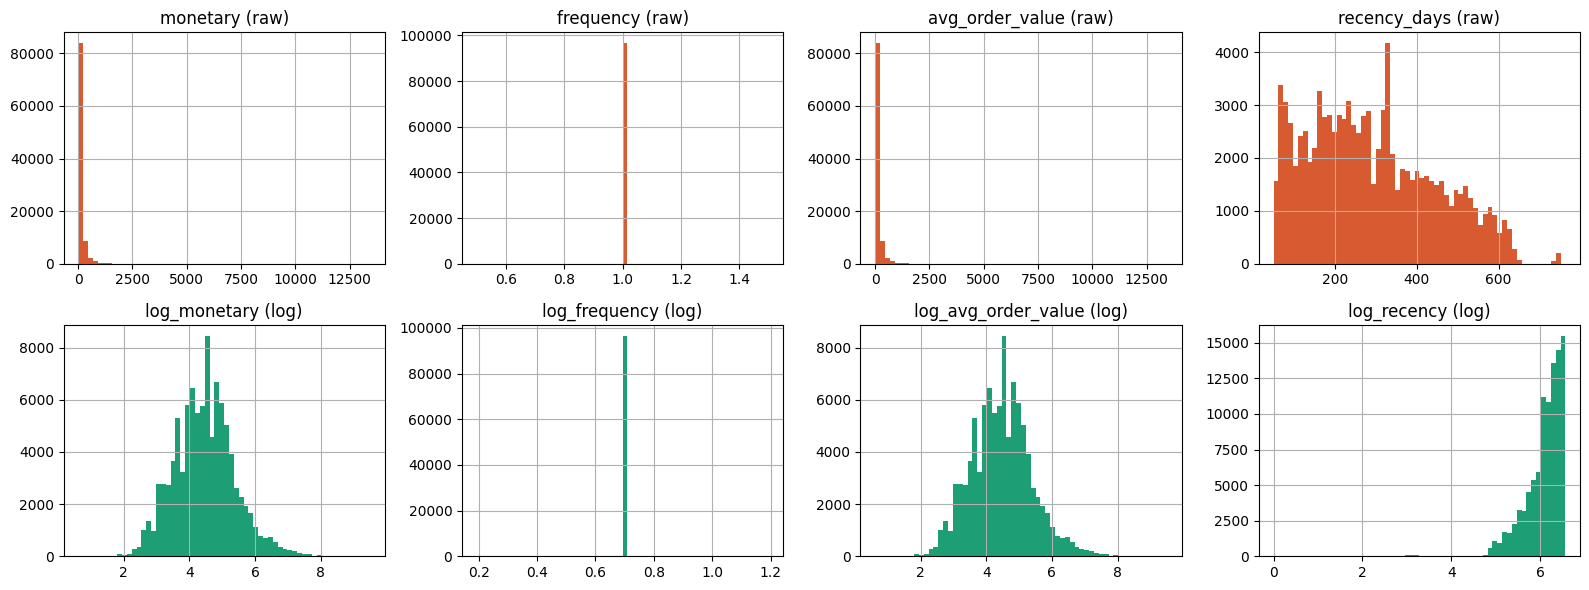

Chart saved to charts/skewness_before_after.png


In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

pairs = [
    ('monetary',        'log_monetary'),
    ('frequency',       'log_frequency'),
    ('avg_order_value', 'log_avg_order_value'),
    ('recency_days',    'log_recency'),
]

for i, (raw_col, log_col) in enumerate(pairs):
    features[raw_col].hist(bins=60, ax=axes[0][i], color='#D85A30')
    axes[0][i].set_title(f'{raw_col} (raw)')

    features[log_col].hist(bins=60, ax=axes[1][i], color='#1D9E75')
    axes[1][i].set_title(f'{log_col} (log)')

plt.tight_layout()
plt.savefig('charts/skewness_before_after.png', dpi=150)
plt.show()
print("Chart saved to charts/skewness_before_after.png")

In [14]:
print("Missing values per column:")
print(features.isnull().sum()[features.isnull().sum() > 0])

Missing values per column:
avg_review_score         646
avg_delivery_days          8
avg_delivery_delta         8
late_deliveries            8
preferred_payment          1
avg_installments           1
max_installments           1
high_installment_flag      1
dtype: int64


In [15]:
# Customers with no review → fill avg score with dataset median, reviewer flag = 0
median_review = features['avg_review_score'].median()
features['avg_review_score']     = features['avg_review_score'].fillna(median_review)
features['review_count']         = features['review_count'].fillna(0)
features['is_reviewer']          = features['is_reviewer'].fillna(0)

# Delivery features: customers with no delivery data (edge case) → fill with medians
for col in ['avg_delivery_days', 'avg_delivery_delta', 'late_deliveries']:
    features[col] = features[col].fillna(features[col].median())

# Payment installments: fill with 1 (single payment assumed)
features['avg_installments']     = features['avg_installments'].fillna(1.0)
features['max_installments']     = features['max_installments'].fillna(1)
features['high_installment_flag']= features['high_installment_flag'].fillna(0)

# Category diversity: should always exist for delivered orders, but just in case
features['category_diversity']   = features['category_diversity'].fillna(1)

# Freight ratio: fill with median
features['freight_to_revenue_ratio'] = features['freight_to_revenue_ratio'].fillna(
    features['freight_to_revenue_ratio'].median()
)

print("\nMissing values after fill:")
print(features.isnull().sum()[features.isnull().sum() > 0])
print("(Empty output means no missing values remain)")


Missing values after fill:
preferred_payment    1
dtype: int64
(Empty output means no missing values remain)


In [16]:
# One customer has no payment record whatsoever — fill with dataset mode
most_common_payment = features['preferred_payment'].mode()[0]
features['preferred_payment'] = features['preferred_payment'].fillna(most_common_payment)

print(f"Filled missing preferred_payment with mode: '{most_common_payment}'")

Filled missing preferred_payment with mode: 'credit_card'


In [17]:
missing = features.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("All clear — 0 missing values across all columns.")
else:
    print("Still missing:")
    print(missing)

All clear — 0 missing values across all columns.


In [18]:
# Save full feature store (with raw columns intact for inspection)
features.to_csv("data/processed/customer_features.csv", index=False)
print(f"Saved: data/processed/customer_features.csv")
print(f"Shape: {features.shape}")

# Quick sanity check
check = pd.read_csv("data/processed/customer_features.csv")
print(f"Reload check: {check.shape}")
print(check[['customer_id', 'recency_days', 'frequency', 'monetary',
             'category_diversity', 'avg_review_score']].describe().round(2))

Saved: data/processed/customer_features.csv
Shape: (96478, 26)
Reload check: (96478, 26)
       recency_days  frequency  monetary  category_diversity  avg_review_score
count      96478.00    96478.0  96478.00            96478.00          96478.00
mean         289.66        1.0    137.04                1.01              4.16
std          152.84        0.0    209.05                0.09              1.28
min           50.00        1.0      0.85                1.00              1.00
25%          166.00        1.0     45.90                1.00              4.00
50%          271.00        1.0     86.57                1.00              5.00
75%          399.00        1.0    149.90                1.00              5.00
max          763.00        1.0  13440.00                3.00              5.00
